# print ready
We use 1x1 smooth lego pieces on a 48x48 base plate as a relief print matrix. Here we use methods from `PixelfyOps` to create and visualise print patterns. The edge length of the used lego piece is 7.8 mm.

In [1]:
# all sizes in cm
px_size = 0.78
border = px_size*2
DINA_sizes = {0 : (84.1, 118.9),
              1 : (59.4, 84.1),
              2 : (42.0, 59.4),
              3 : (29.7, 42.0), 
              4 : (21.0, 29.7)
             }


print(f'DIN paper sizes and corresponding biggest pixel format (with {border}cm border):')
for key, (x,y) in DINA_sizes.items():
    x_px = int((x-(border*2))/px_size)
    y_px = int((y-(border*2))/px_size)
    print(f'  DINA{key}: {x}{y}cm, {x_px}x{y_px}px')

print()
print('Pixel sizes converted to lengths:')
    
for x in [32,48,64,96,128]:
    x_cm = x * px_size
    print(f'  {x}px: {x_cm}cm')

DIN paper sizes and corresponding biggest pixel format (with 1.56cm border):
  DINA0: 84.1118.9cm, 103x148px
  DINA1: 59.484.1cm, 72x103px
  DINA2: 42.059.4cm, 49x72px
  DINA3: 29.742.0cm, 34x49px
  DINA4: 21.029.7cm, 22x34px

Pixel sizes converted to lengths:
  32px: 24.96cm
  48px: 37.44cm
  64px: 49.92cm
  96px: 74.88cm
  128px: 99.84cm


## image based monocrome

lets start with a short look at the sample images. 48px on the long edge is the biggest plate we can produce. printing only one color (black) would look like this:

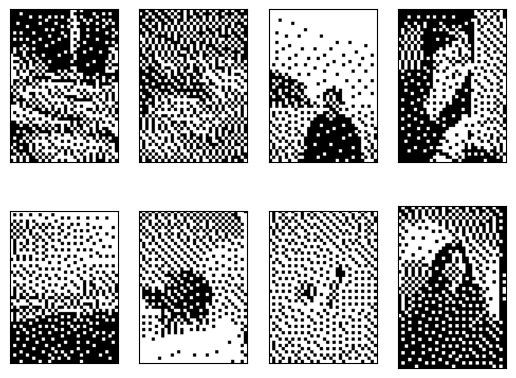

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
from pixelfy import Pixelfy, PixelfyOps
from PIL import Image

import matplotlib.pyplot as plt
import os 
    
directory = '../img/photo'
files = sorted([os.path.join(directory,f) for f in os.listdir(directory) if f.endswith('.jpg')])
palette = [(0,0,0), (255,255,255)]

fig, axs = plt.subplots(2,4)
axs = axs.ravel()
for f, ax in zip(files, axs):
    im = Image.open(f)
    px = Pixelfy(im, upscaling=10, resolution=(48,48), dithering=0.6)
    px.set_palette(palette)
    ax.imshow(px.make())
    ax.set_xticks([])
    ax.set_yticks([])

this is ok for some images, but clearly shows the limits of what can be achieved. some images (high contrast, recognisable content) work better than others. but of course 32x32 graphics have been used in e.g. early computer games or icons. this leads us to other subjects to print.

## direct 32x32 pixel drawing based monocrome

we use a pixel drawing program to directly draw in the desired format. programs like this are simple and thus exist in many forms, both we based (e.g. [pixilart.com]{https://www.pixilart.com/draw}) and as apps. A selection of these drawing has been added to the sample images.

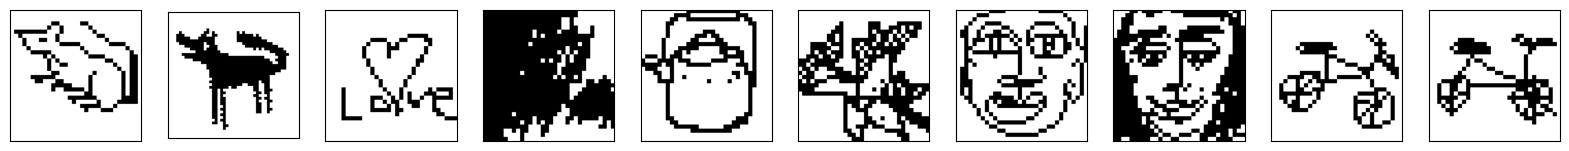

In [3]:
directory = '../img/drawing'
files = sorted([os.path.join(directory,f) for f in os.listdir(directory) if f.endswith('.png')])
palette = [(0,0,0), (255,255,255)]

fig, axs = plt.subplots(1,len(files), figsize=(20,3))
axs = axs.ravel()
for f, ax in zip(files, axs):
    im = Image.open(f)
    im = Image.alpha_composite(Image.new('RGBA', im.size, (255,255,255,255)), im.convert('RGBA')).convert('RGB')
    px = Pixelfy(im, upscaling=10, resolution=(48,48), dithering=0.6)
    px.set_palette(palette)
    im = px.make()
    ax.imshow(im)
    ax.set_xticks([])
    ax.set_yticks([])

Now we use python only to mirror the image and make the layout more *readable* by adding grid lines.

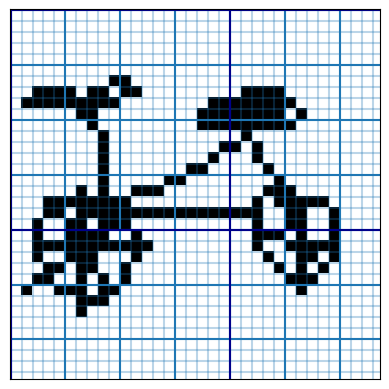

In [4]:
def ax_gridded_imshow(ax, img, scaling=10, mayor={5:'tab:blue',20:'darkblue',48:'tab:red'}):
    width, height = img.size
    img = img.transpose(Image.FLIP_LEFT_RIGHT)
    img = PixelfyOps.scale_up(img, scaling=scaling)
    ax.imshow(img)
    for v in [i*scaling for i in range( width+2)]: ax.axvline(v, alpha=0.3)
    for h in [i*scaling for i in range(height+2)]: ax.axhline(h, alpha=0.3)
    for k,color in mayor.items():
        if k < width:
            for v in [i*scaling*k for i in range(int( width/k)+1)]: ax.axvline(v, color=color)
        if k < height:
            for h in [i*scaling*k for i in range(int(height/k)+1)]: ax.axhline(h, color=color)
    ax.set_xticks([])
    ax.set_yticks([])
    return ax

palette = [(0,0,0), (255,255,255)]
img = Image.open(f)
img = Image.alpha_composite(Image.new('RGBA', img.size, (255,255,255,255)), img.convert('RGBA')).convert('RGB')
img = img.convert("RGB")
img = PixelfyOps.variable_dither(img, strength=0.55, palette=palette)

fig, ax = plt.subplots()
ax = ax_gridded_imshow(ax, img)
plt.show()

## abstract monocrome

another idea is to generate abstract patterns. I vibe coded some pattern generators that rely on a variety of different mechanisms. Some are inherently monochrome, some are greyscale. But since there is no figurative content to be recognised, they work well in black and white, too.

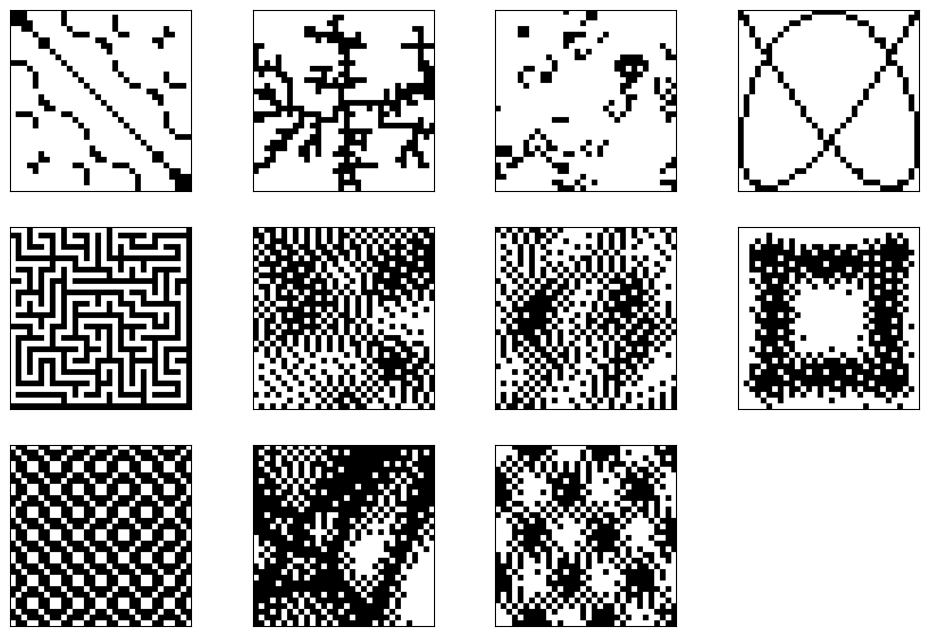

In [5]:
import pattern 
import inspect

seed = 187
palette = [(0,0,0),(255,255,255)]
generators = [obj for name, obj in inspect.getmembers(pattern, inspect.isclass)
              if name.endswith('Generator') and name != 'Generator']


fig, axs = plt.subplots(3,4, figsize=(12,8))
axs = axs.ravel()

for gen, ax in zip(generators, axs):
    try:
        img = gen(seed=seed).generate()
    except TypeError:
        img = gen().generate()
    
    img = img.convert("RGB")
    img = PixelfyOps.variable_dither(img, strength=0.55, palette=palette)
    img = img.resize((320, 320), Image.NEAREST)
    
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])

fig.delaxes(axs[-1])


## image based multicolor

Printing monochrome is fast and easy. Apart from that there is no real reason to not print colors. It is actually suprisingly easy to print multiple colors on the lego plate, since the dots are well restricted to the grid. Using more colors also allows us to create recognisable images in our restricted pixel space. Available options are e.g.:
- greyscale
- primary colors
- infer colors from the image

In [6]:
directory = '../img/photo'
files = sorted([os.path.join(directory,f) for f in os.listdir(directory) if f.endswith('.jpg')])

once again, black and white for comparison:

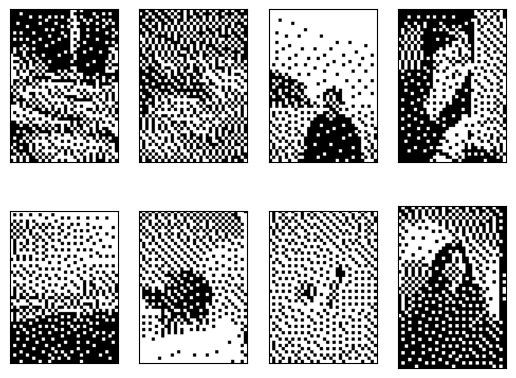

In [7]:
palette = [(0,0,0), (255,255,255)]

fig, axs = plt.subplots(2,4)
for f, ax in zip(files, axs.ravel()):
    px = Pixelfy(Image.open(f), upscaling=10, resolution=(48,48), dithering=0.6)
    px.set_palette(palette)
    ax.imshow(px.make())
    ax.set_xticks([]); ax.set_yticks([])

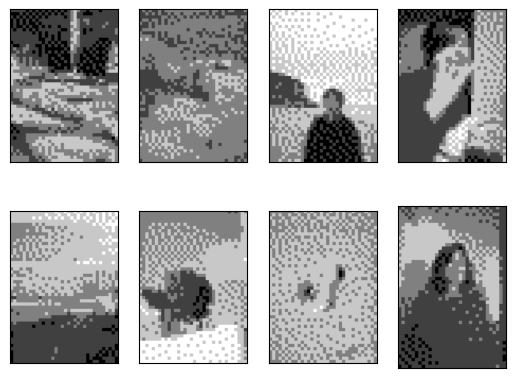

In [8]:
palette = [(x,x,x) for x in [0,64,128,200,255]]

fig, axs = plt.subplots(2,4)
for f, ax in zip(files, axs.ravel()):
    px = Pixelfy(Image.open(f), upscaling=10, resolution=(48,48), dithering=0.6)
    px.set_palette(palette)
    ax.imshow(px.make())
    ax.set_xticks([]); ax.set_yticks([])

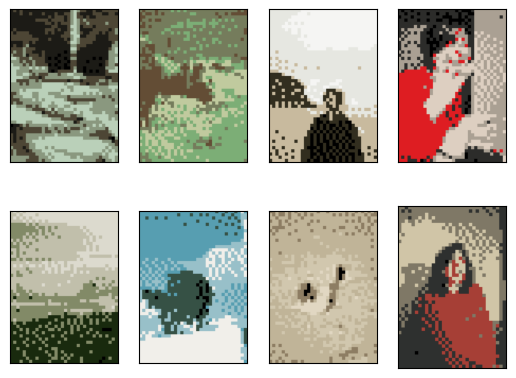

In [9]:
fig, axs = plt.subplots(2,4)
for f, ax in zip(files, axs.ravel()):
    px = Pixelfy(Image.open(f), upscaling=10, resolution=(48,48), dithering=0.6)
    px.set_palette(PixelfyOps.infer_palette(Image.open(f), 4))
    ax.imshow(px.make())
    ax.set_xticks([]); ax.set_yticks([])

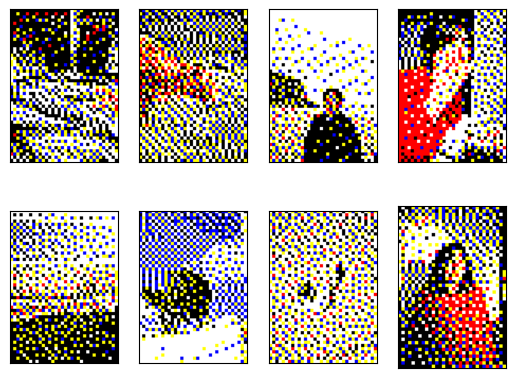

In [10]:
palette = [(0,0,0), (0,0,255), (255,255,0), (255,0,0), (255,255,255)]

fig, axs = plt.subplots(2,4)
for f, ax in zip(files, axs.ravel()):
    px = Pixelfy(Image.open(f), upscaling=10, resolution=(48,48), dithering=0.6)
    px.set_palette(palette)
    ax.imshow(px.make())
    ax.set_xticks([]); ax.set_yticks([])

In [11]:
from PIL import Image
from collections import Counter
import math
from matplotlib import colors as mcolors

def separate_colors(img: Image.Image, background=(0, 0, 0, 0)):
    """
    Split an image into one image per exact RGB color.

    Parameters
    ----------
    img : PIL.Image.Image
        Input image.
    background : tuple
        RGBA color to use for non-matching pixels in each output image.
        Default is fully transparent.

    Returns
    -------
    dict
        {(R, G, B): PIL.Image.Image, ...}
    """
    rgba = img.convert("RGBA") # in case of transparency
    pixels = list(rgba.get_flattened_data())
    unique_colors = sorted({(r, g, b) for (r, g, b, a) in pixels if a != 0}) # but ignoring alpha for the list of colors

    result = {}
    width, height = rgba.size

    for color in unique_colors:
        out = Image.new("RGBA", (width, height), background)
        out_pixels = []

        for px in pixels:
            r, g, b, a = px
            if a != 0 and (r, g, b) == color:
                out_pixels.append((r, g, b, a))
            else:
                out_pixels.append(background)

        out.putdata(out_pixels)
        result[color] = out
    return result

def nearest_css4_color_name(rgb):
    """
    Return the nearest CSS4 named color from matplotlib.
    
    Example:
        (200, 200, 200) -> 'silver' or 'lightgray'
    """
    CSS4_RGB = {
        name: tuple(int(round(c * 255)) for c in mcolors.to_rgb(hex_value))
        for name, hex_value in mcolors.CSS4_COLORS.items()
    }
    r, g, b = rgb
    best_name = None
    best_dist = float("inf")

    for name, (cr, cg, cb) in CSS4_RGB.items():
        # 3D euclidian distance 
        dist = math.sqrt((r - cr)**2 + (g - cg)**2 + (b - cb)**2)
        if dist < best_dist:
            best_dist = dist
            best_name = name

    return best_name

def color_histogram(img: Image.Image, flatten_bg=None) -> dict:
    """
    Return a dict mapping (R,G,B) -> count.
    If flatten_bg=(r,g,b) is provided and the image has alpha, it is composited over that color first.
    """
    im = img
    if flatten_bg is not None:
        im = Image.alpha_composite(
            Image.new('RGBA', im.size, (*flatten_bg, 255)),
            im.convert('RGBA')
        ).convert('RGB')
    else:
        if im.mode != 'RGB':
            im = im.convert('RGB')
    return dict(Counter(im.get_flattened_data()))

def hexcolor(rgb):
    """"takes color as rgb integer tuple and returns hexcode string"""
    r, g, b = rgb
    return f"#{r:02x}{g:02x}{b:02x}"

def fig_seperated_colors(img, scaling=10, fig_width=4):
    channels = separate_colors(img)
    count = color_histogram(img)
    fig, axs = plt.subplots(1, len(channels)+1, figsize=((len(channels)+1)*fig_width,fig_width*1.5))
    axs[0] = ax_gridded_imshow(axs[0], img)
    axs[0].set_title(f'size: {img.size[1]*px_size:.1f} x {img.size[0]*px_size:.1f} cm')
    for ax, (color, img) in zip(axs[1::], channels.items()):
        # blackify the image (channel):
        r, g, b, a = img.split()
        z = Image.new('L', img.size, 0)   # zero channel
        img = Image.merge('RGBA', (z, z, z, a))
        ax = ax_gridded_imshow(ax, img)
        ax.set_title(f"{nearest_css4_color_name(color)} ({hexcolor(color)}): {(count[color])}px")
    return fig, axs

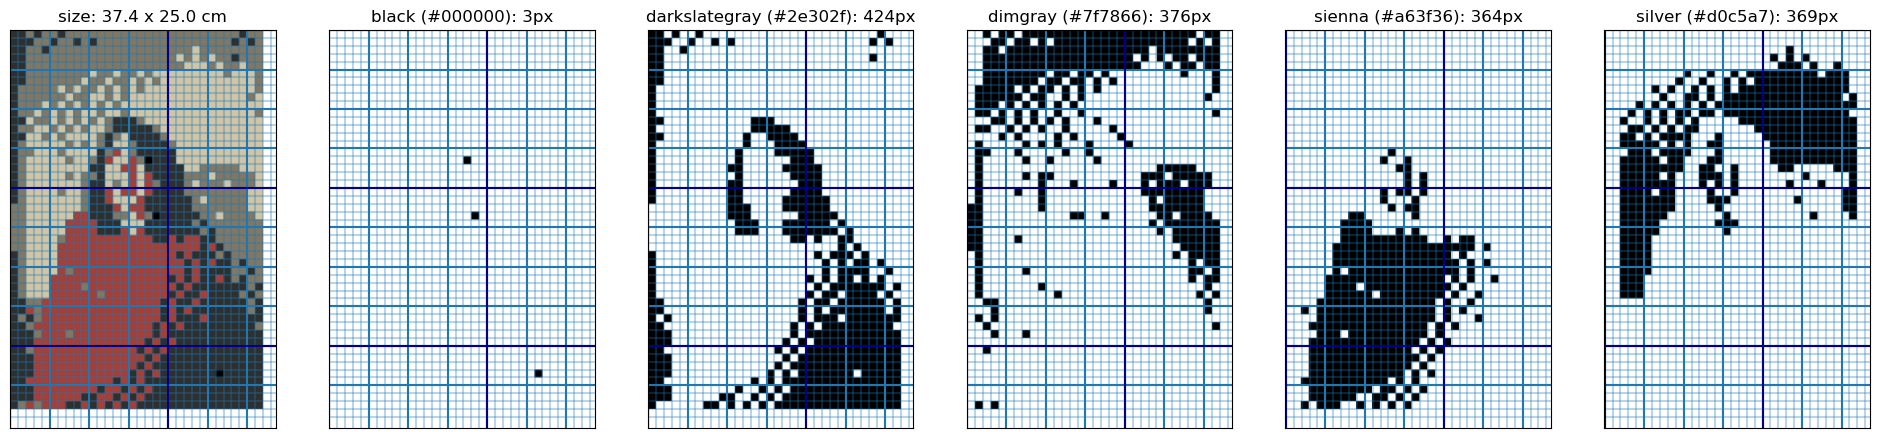

In [12]:
px = Pixelfy(Image.open(files[-1]), upscaling=1, resolution=(48,48), dithering=0.6)
px.set_palette(PixelfyOps.infer_palette(Image.open(f), 4))
img = px.make()
fig, ax = fig_seperated_colors(img)

obviously we can scrap the color black in this one.

## finding a sweet spot

In [13]:
directory = '../img/foto_hc'
files = sorted([os.path.join(directory,f) for f in os.listdir(directory) if f.endswith('.png')])

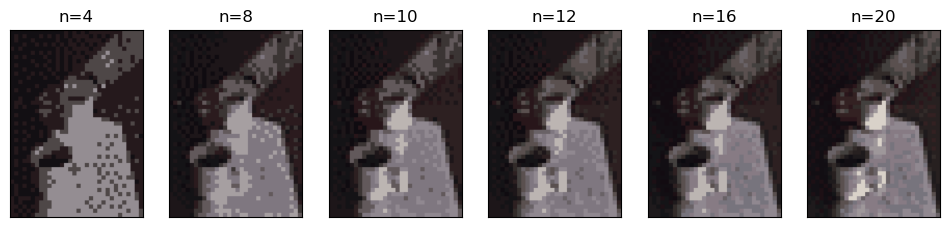

In [14]:
def fig_ncolor_find(f, nset=[4,8,10,12,16, 20], infer=True, palette=False, resolution=(45,45)):
    fig, axs = plt.subplots(1,len(nset), figsize=(len(nset)*2,3))
    axs = axs.ravel()
    for ncolors, ax in zip(nset, axs):
        img = Image.open(f)
        img = Image.alpha_composite(Image.new('RGBA', img.size, (255,255,255,255)), img.convert('RGBA')).convert('RGB')
        if infer: palette = PixelfyOps.infer_palette(img, ncolors=ncolors)
        px = Pixelfy(img, upscaling=1, resolution=resolution, dithering=0.9)
        px.set_palette(palette)
        img = px.make()
        ax.set_title(f'n={ncolors}')
        
        img = PixelfyOps.scale_up(img,10)
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
    return fig, axs

fig, axs = fig_ncolor_find(files[3])

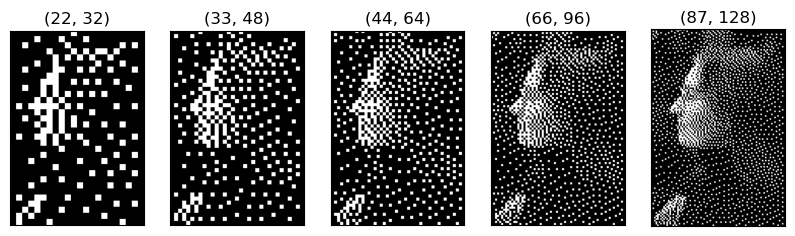

In [15]:
def fig_resolution_find(f, res_set=[20,25,32,48,100], palette=[(0,0,0), (255,255,255)]):
    
    fig, axs = plt.subplots(1,len(res_set), figsize=(len(res_set)*2,3))
    axs = axs.ravel()
    for res, ax in zip(res_set, axs):
        resolution = (res,res)
        img = Image.open(f)
        img = Image.alpha_composite(Image.new('RGBA', img.size, (255,255,255,255)), img.convert('RGBA')).convert('RGB')
        px = Pixelfy(img, upscaling=1, resolution=resolution, dithering=0.9)
        px.set_palette(palette)
        img = px.make()
        ax.set_title(f'{img.size}')
        
        img = PixelfyOps.scale_up(img,10)
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
    return fig, axs

fig, axs = fig_resolution_find(files[2], [32, 48, 64, 96, 128, ])

## code compendium for export

In [16]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
from pixelfy import Pixelfy, PixelfyOps
from PIL import Image

import matplotlib.pyplot as plt
import os 

from collections import Counter
import math
from matplotlib import colors as mcolors


PX_SIZE = 0.78
DINA_SIZES = {0 : (84.1, 118.9),
              1 : (59.4, 84.1),
              2 : (42.0, 59.4),
              3 : (29.7, 42.0), 
              4 : (21.0, 29.7)
             }

def ax_gridded_imshow(ax, img, scaling=10, mayor={5:'tab:blue',20:'darkblue',48:'tab:red'}):
    width, height = img.size
    img = img.transpose(Image.FLIP_LEFT_RIGHT)
    img = PixelfyOps.scale_up(img, scaling=scaling)
    ax.imshow(img)
    for v in [i*scaling for i in range( width+2)]: ax.axvline(v, alpha=0.3)
    for h in [i*scaling for i in range(height+2)]: ax.axhline(h, alpha=0.3)
    for k,color in mayor.items():
        if k < width:
            for v in [i*scaling*k for i in range(int( width/k)+1)]: ax.axvline(v, color=color)
        if k < height:
            for h in [i*scaling*k for i in range(int(height/k)+1)]: ax.axhline(h, color=color)
    ax.set_xticks([])
    ax.set_yticks([])
    return ax

def separate_colors(img: Image.Image, background=(0, 0, 0, 0)):
    """
    Split an image into one image per exact RGB color.

    Parameters
    ----------
    img : PIL.Image.Image
        Input image.
    background : tuple
        RGBA color to use for non-matching pixels in each output image.
        Default is fully transparent.

    Returns
    -------
    dict
        {(R, G, B): PIL.Image.Image, ...}
    """
    rgba = img.convert("RGBA") # in case of transparency
    pixels = list(rgba.get_flattened_data())
    unique_colors = sorted({(r, g, b) for (r, g, b, a) in pixels if a != 0}) # but ignoring alpha for the list of colors

    result = {}
    width, height = rgba.size

    for color in unique_colors:
        out = Image.new("RGBA", (width, height), background)
        out_pixels = []

        for px in pixels:
            r, g, b, a = px
            if a != 0 and (r, g, b) == color:
                out_pixels.append((r, g, b, a))
            else:
                out_pixels.append(background)

        out.putdata(out_pixels)
        result[color] = out
    return result

def nearest_css4_color_name(rgb):
    """
    Return the nearest CSS4 named color from matplotlib.
    
    Example:
        (200, 200, 200) -> 'silver' or 'lightgray'
    """
    CSS4_RGB = {
        name: tuple(int(round(c * 255)) for c in mcolors.to_rgb(hex_value))
        for name, hex_value in mcolors.CSS4_COLORS.items()
    }
    r, g, b = rgb
    best_name = None
    best_dist = float("inf")

    for name, (cr, cg, cb) in CSS4_RGB.items():
        # 3D euclidian distance 
        dist = math.sqrt((r - cr)**2 + (g - cg)**2 + (b - cb)**2)
        if dist < best_dist:
            best_dist = dist
            best_name = name

    return best_name

def color_histogram(img: Image.Image, flatten_bg=None) -> dict:
    """
    Return a dict mapping (R,G,B) -> count.
    If flatten_bg=(r,g,b) is provided and the image has alpha, it is composited over that color first.
    """
    im = img
    if flatten_bg is not None:
        im = Image.alpha_composite(
            Image.new('RGBA', im.size, (*flatten_bg, 255)),
            im.convert('RGBA')
        ).convert('RGB')
    else:
        if im.mode != 'RGB':
            im = im.convert('RGB')
    return dict(Counter(im.get_flattened_data()))

def hexcolor(rgb):
    """"takes color as rgb integer tuple and returns hexcode string"""
    r, g, b = rgb
    return f"#{r:02x}{g:02x}{b:02x}"

def fig_seperated_colors(img, scaling=10, fig_width=4):
    channels = separate_colors(img)
    count = color_histogram(img)
    fig, axs = plt.subplots(1, len(channels)+1, figsize=((len(channels)+1)*fig_width,fig_width*1.5))
    axs[0] = ax_gridded_imshow(axs[0], img)
    axs[0].set_title(f'size: {img.size[1]*PX_SIZE:.1f} x {img.size[0]*PX_SIZE:.1f} cm')
    for ax, (color, img) in zip(axs[1::], channels.items()):
        # blackify the image (channel):
        r, g, b, a = img.split()
        z = Image.new('L', img.size, 0)   # zero channel
        img = Image.merge('RGBA', (z, z, z, a))
        ax = ax_gridded_imshow(ax, img)
        ax.set_title(f"{nearest_css4_color_name(color)} ({hexcolor(color)}): {(count[color])}px")
    return fig, axs

## =========================

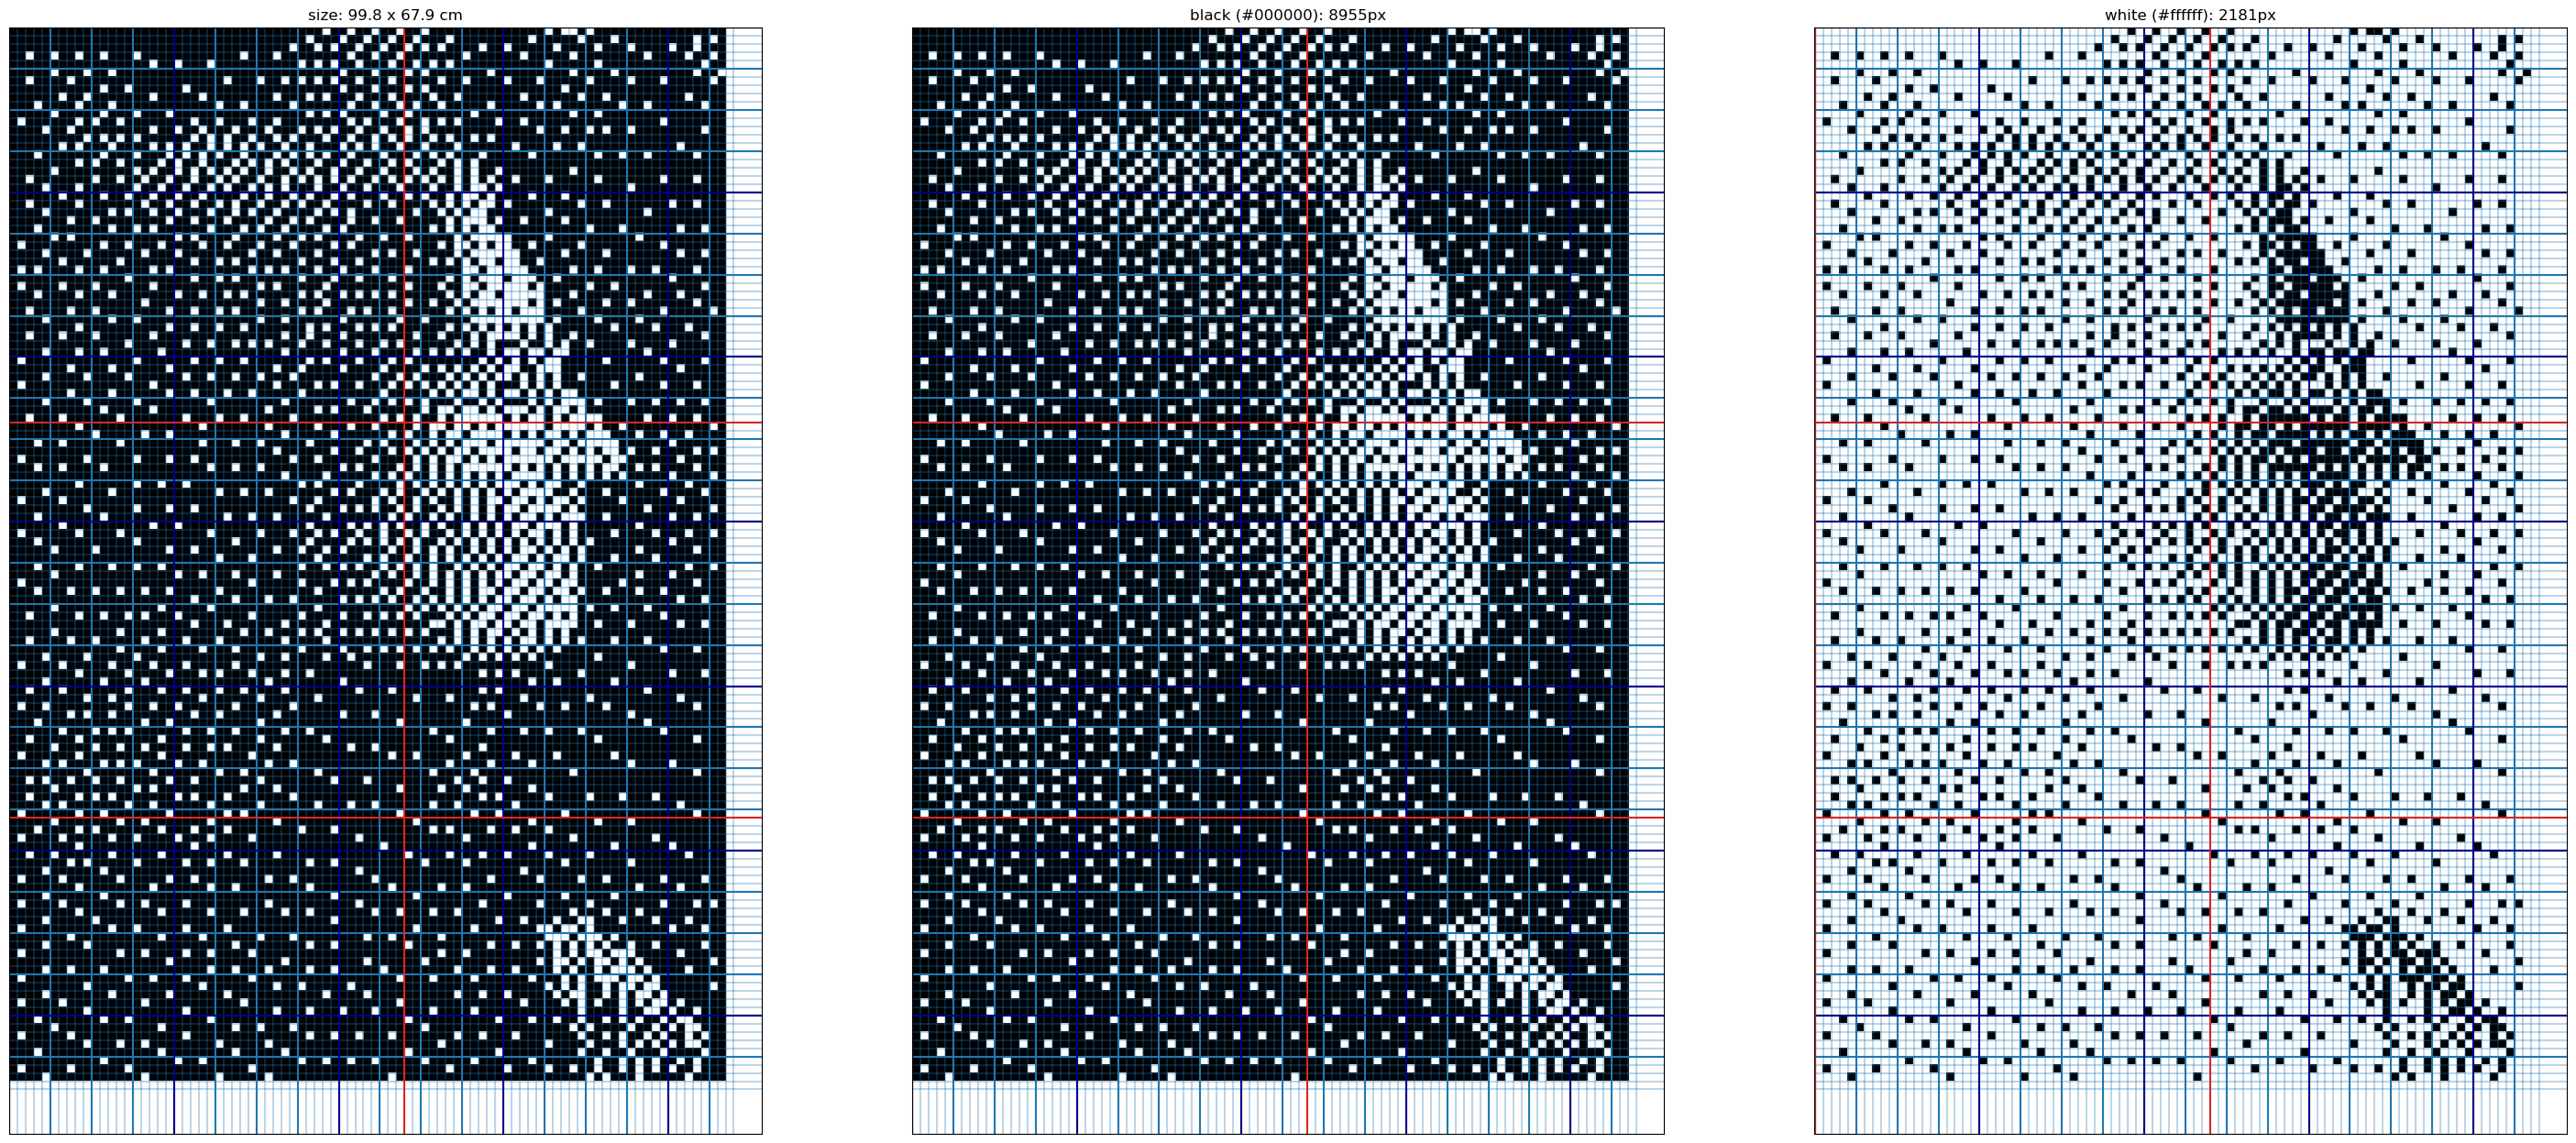

In [17]:
img = Image.open(files[2])
img = Image.alpha_composite(Image.new('RGBA', img.size, (255,255,255,255)), img.convert('RGBA')).convert('RGB')
px = Pixelfy(img, upscaling=1, resolution=(128,128), dithering=1)
px.set_palette([(0,0,0),(255,255,255)])
img = px.make()

fig, axs = fig_seperated_colors(img, fig_width=12)

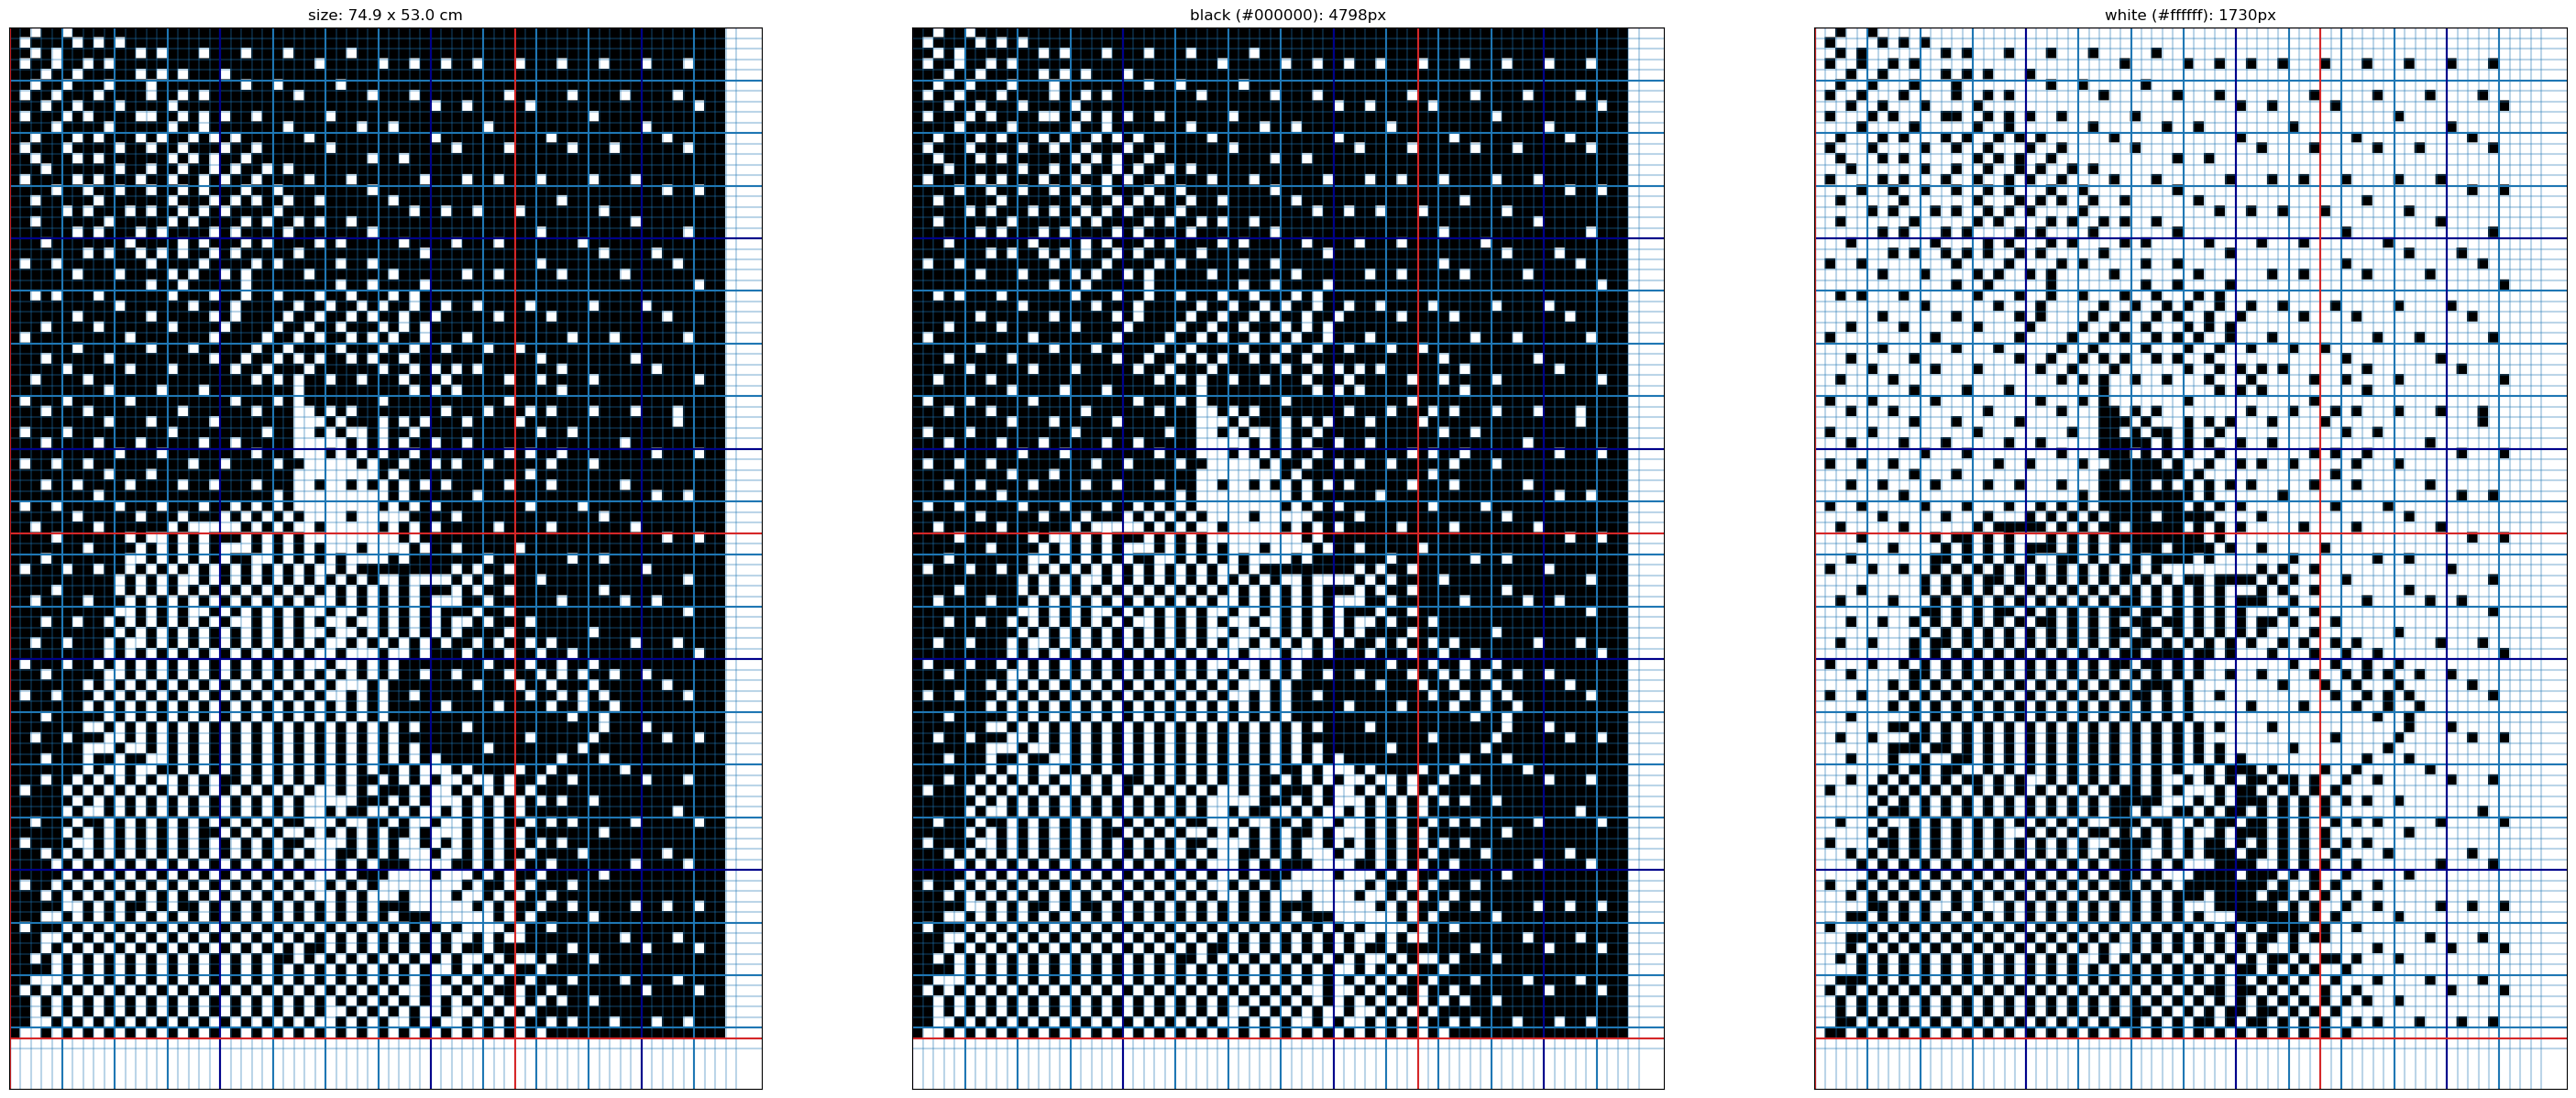

In [18]:
img = Image.open(files[3])
img = Image.alpha_composite(Image.new('RGBA', img.size, (255,255,255,255)), img.convert('RGBA')).convert('RGB')
px = Pixelfy(img, upscaling=1, resolution=(96,96), dithering=1)
px.set_palette([(0,0,0),(255,255,255)])
img = px.make()

fig, axs = fig_seperated_colors(img, fig_width=12)

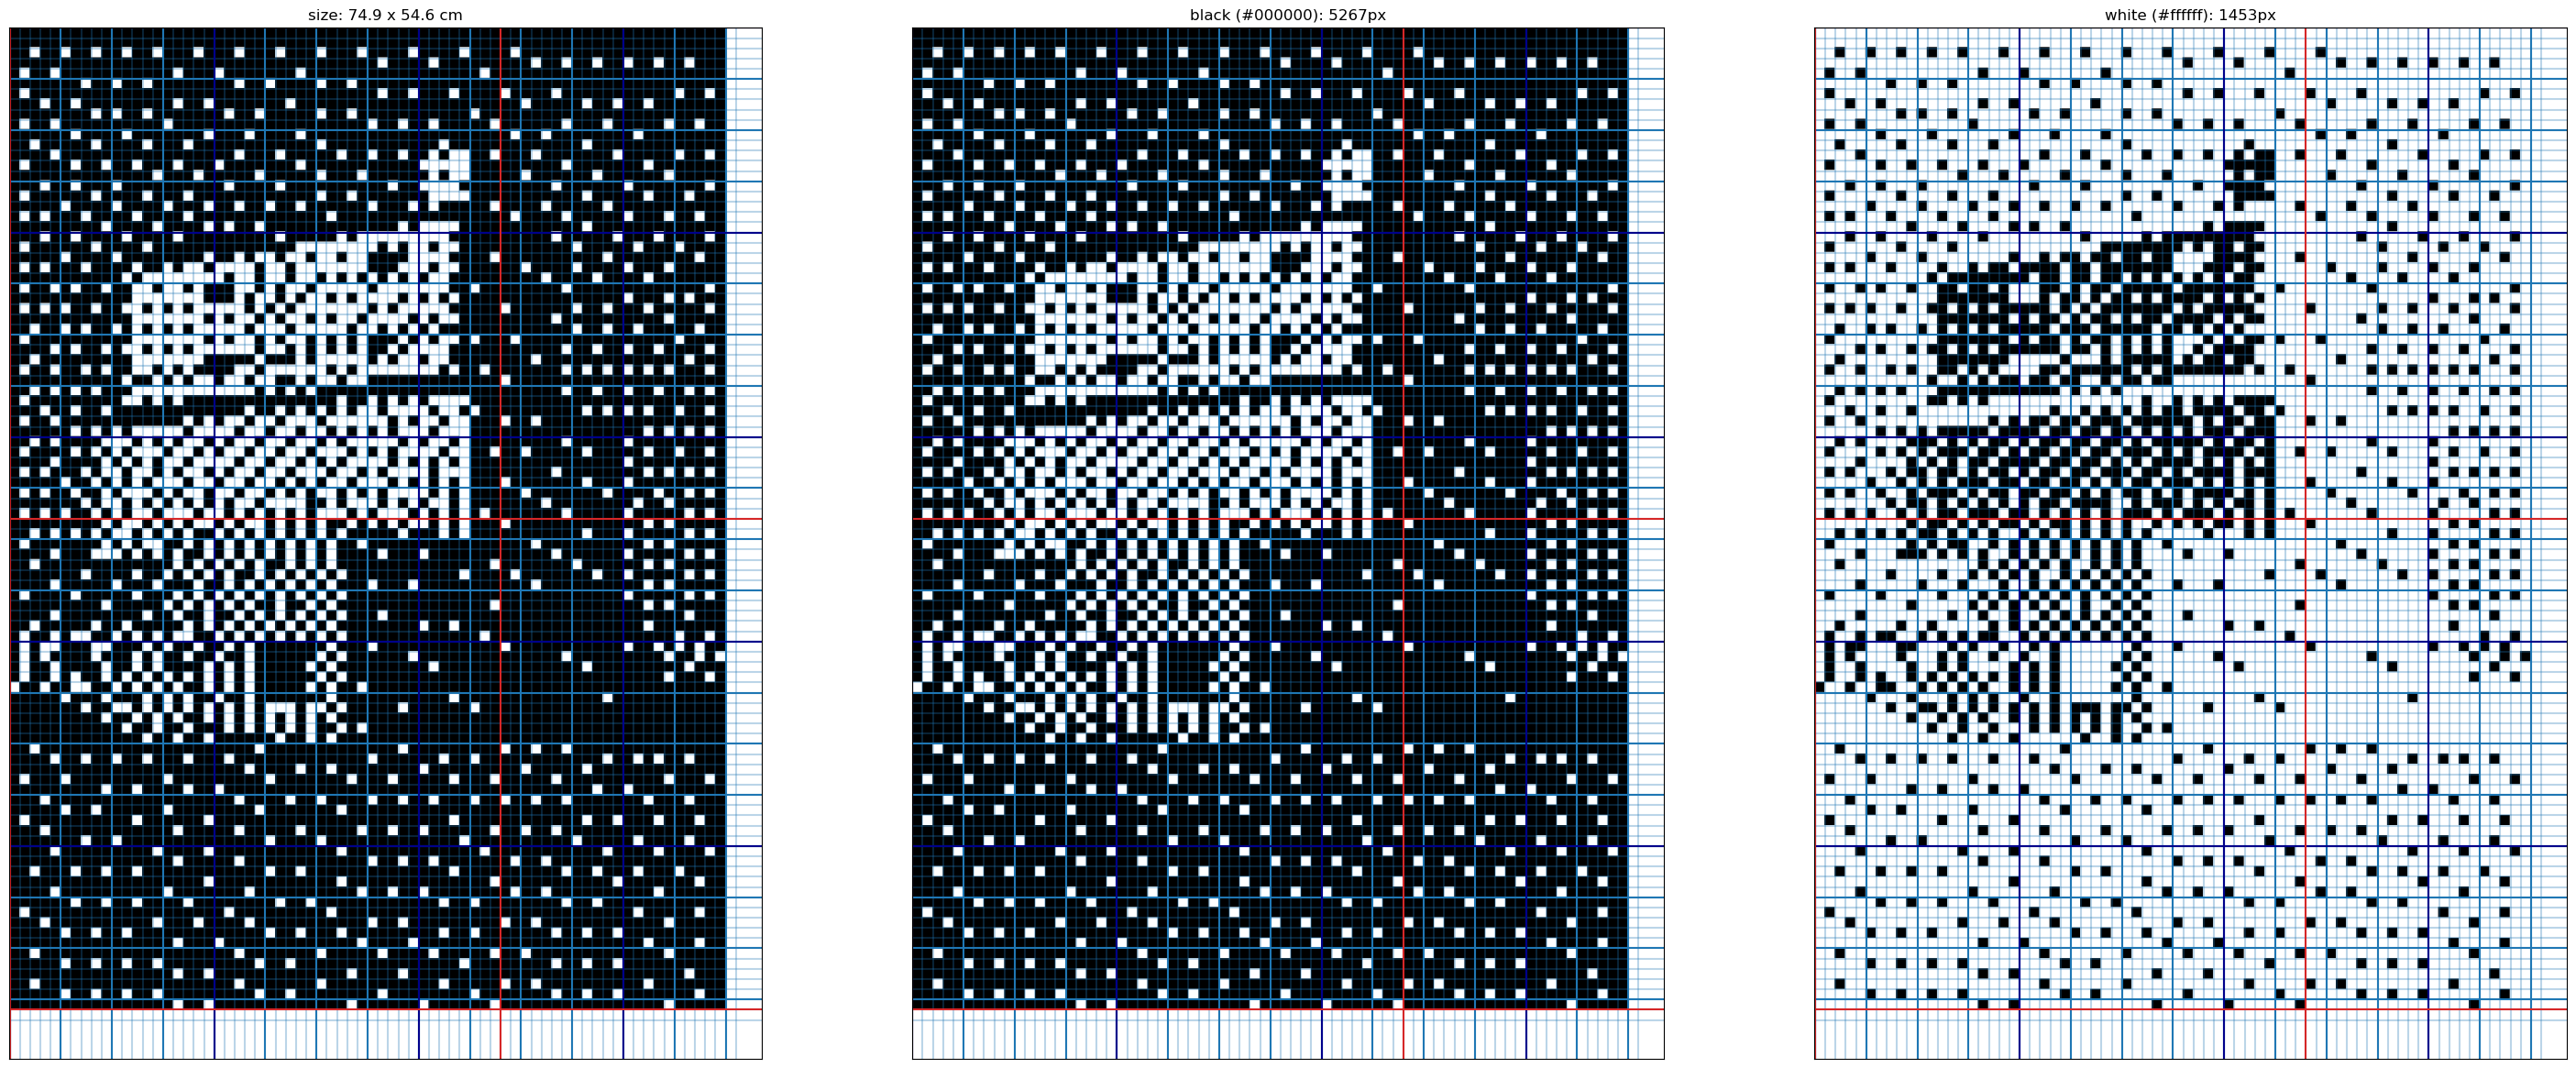

In [19]:
img = Image.open(files[4])
img = Image.alpha_composite(Image.new('RGBA', img.size, (255,255,255,255)), img.convert('RGBA')).convert('RGB')
px = Pixelfy(img, upscaling=1, resolution=(96,96), dithering=1)
px.set_palette([(0,0,0),(255,255,255)])
img = px.make()

fig, axs = fig_seperated_colors(img, fig_width=12)

In [20]:
stop()

NameError: name 'stop' is not defined

In [41]:
directory = '../img/foto_hc'
files = sorted([os.path.join(directory,f) for f in os.listdir(directory) if f.endswith('.png')])

In [37]:
directory = '../img/photo'
files = sorted([os.path.join(directory,f) for f in os.listdir(directory) if f.endswith('.jpg')])

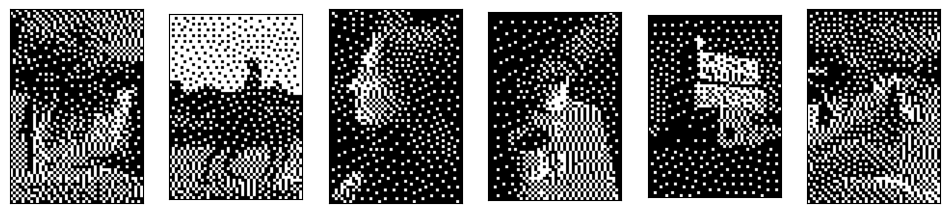

In [43]:
resolution = (46,90)
palette = [(0,0,0),(255,255,255)]

fig, axs = plt.subplots(1,len(files), figsize=(len(files)*2,3))
for f, ax in zip(files, axs.ravel()):
    img = Image.open(f)
    img = Image.alpha_composite(Image.new('RGBA', img.size, (255,255,255,255)), img.convert('RGBA')).convert('RGB')
    px = Pixelfy(img, upscaling=1, resolution=resolution, dithering=0.9)
    px.set_palette(palette)
    img = px.make()
    
    img = PixelfyOps.scale_up(img,10)
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])

In [ ]:
directory = '../img/foto_hc'
files = sorted([os.path.join(directory,f) for f in os.listdir(directory) if f.endswith('.png')])


palette = [(0,0,0), (255,255,255)]
# palette = [(0,0,0), (0,0,255), (255,255,0), (255,0,0), (255,255,255)]
# palette = greyscale_palette(4)
infer = True
resolution = (48,48)
ncolors = 8


fig, axs = plt.subplots(1,len(files), figsize=(20,3))
axs = axs.ravel()
for f, ax in zip(files, axs):
    img = Image.open(f)
    img = Image.alpha_composite(Image.new('RGBA', img.size, (255,255,255,255)), img.convert('RGBA')).convert('RGB')
    if infer: palette = PixelfyOps.infer_palette(img, ncolors=ncolors)
    px = Pixelfy(img, upscaling=1, resolution=resolution, dithering=0.9)
    px.set_palette(palette)
    img = px.make()
    ax.set_title(img.size)
    
    img = PixelfyOps.scale_up(img,10)
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])


In [ ]:
def fig_ncolor_find(f, nset=[4,8,10,12,16, 20], infer=True, palette=False):
    fig, axs = plt.subplots(1,len(nset), figsize=(len(nset)*2,3))
    axs = axs.ravel()
    for ncolors, ax in zip(nset, axs):
        img = Image.open(f)
        img = Image.alpha_composite(Image.new('RGBA', img.size, (255,255,255,255)), img.convert('RGBA')).convert('RGB')
        if infer: palette = PixelfyOps.infer_palette(img, ncolors=ncolors)
        px = Pixelfy(img, upscaling=1, resolution=resolution, dithering=0.9)
        px.set_palette(palette)
        img = px.make()
        ax.set_title(f'n={ncolors}')
        
        img = PixelfyOps.scale_up(img,10)
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
    return fig, axs

fig, axs = fig_ncolor_find(files[3])

In [ ]:
img = Image.open(files[3])
img = Image.alpha_composite(Image.new('RGBA', img.size, (255,255,255,255)), img.convert('RGBA')).convert('RGB')
if infer: palette = PixelfyOps.infer_palette(img, ncolors=12)
px = Pixelfy(img, upscaling=1, resolution=resolution, dithering=0.9)
px.set_palette(palette)
img = px.make()

fig, axs = fig_seperated_colors(img)
# fig.savefig('/Users/admin/pixel_forge/temp/pixel_forge/img/foto_hc/out.png')
px.preview_palette()

In [ ]:
fig, axs = fig_ncolor_find(files[0], [2,3,4,5,6,8])

In [ ]:
img = Image.open(files[0])
img = Image.alpha_composite(Image.new('RGBA', img.size, (255,255,255,255)), img.convert('RGBA')).convert('RGB')
if infer: palette = PixelfyOps.infer_palette(img, ncolors=4)
px = Pixelfy(img, upscaling=1, resolution=resolution, dithering=0.9)
px.set_palette(palette)
img = px.make()

fig, axs = fig_seperated_colors(img)
# fig.savefig('/Users/admin/pixel_forge/temp/pixel_forge/img/foto_hc/out.png')
px.preview_palette()

In [ ]:
fig, axs = fig_ncolor_find(files[1], [4,5,6,7,8,9])

In [ ]:
def fig_resolution_find(f, res_set=[20,25,32,48,100], palette=[(0,0,0), (255,255,255)]):
    
    fig, axs = plt.subplots(1,len(res_set), figsize=(len(res_set)*2,3))
    axs = axs.ravel()
    for res, ax in zip(res_set, axs):
        resolution = (res,res)
        img = Image.open(f)
        img = Image.alpha_composite(Image.new('RGBA', img.size, (255,255,255,255)), img.convert('RGBA')).convert('RGB')
        # if infer: palette = PixelfyOps.infer_palette(img, ncolors=ncolors)
        px = Pixelfy(img, upscaling=1, resolution=resolution, dithering=0.9)
        px.set_palette(palette)
        img = px.make()
        ax.set_title(f'{img.size}')
        
        img = PixelfyOps.scale_up(img,10)
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
    return fig, axs

fig, axs = fig_resolution_find(files[2], [32, 48, 64, 96, 128, ])

In [ ]:
img = Image.open(files[2])
img = Image.alpha_composite(Image.new('RGBA', img.size, (255,255,255,255)), img.convert('RGBA')).convert('RGB')
px = Pixelfy(img, upscaling=1, resolution=(128,128), dithering=1)
px.set_palette([(0,0,0),(255,255,255)])
img = px.make()
fig, axs = fig_seperated_colors(img, fig_width=12)


In [ ]:
fig, axs = fig_resolution_find(files[4], [32, 48, 64, 96, 128, ])

In [ ]:
fig, axs = fig_resolution_find(files[3], [32, 48, 64, 96, 128, ])

In [ ]:
img = Image.open(files[3])
img = Image.alpha_composite(Image.new('RGBA', img.size, (255,255,255,255)), img.convert('RGBA')).convert('RGB')
px = Pixelfy(img, upscaling=1, resolution=(96,96), dithering=1)
px.set_palette([(0,0,0),(255,255,255)])
img = px.make()

fig, axs = fig_seperated_colors(img, fig_width=12)

In [ ]:
img = Image.open(files[4])
img = Image.alpha_composite(Image.new('RGBA', img.size, (255,255,255,255)), img.convert('RGBA')).convert('RGB')
px = Pixelfy(img, upscaling=1, resolution=(96,96), dithering=1)
px.set_palette([(0,0,0),(255,255,255)])
img = px.make()

fig, axs = fig_seperated_colors(img, fig_width=12)

## Utility functions from this script:

In [ ]:
from PIL import Image
from collections import Counter
import math
from matplotlib import colors as mcolors

def separate_colors(img: Image.Image, background=(0, 0, 0, 0)):
    """
    Split an image into one image per exact RGB color.

    Parameters
    ----------
    img : PIL.Image.Image
        Input image.
    background : tuple
        RGBA color to use for non-matching pixels in each output image.
        Default is fully transparent.

    Returns
    -------
    dict
        {(R, G, B): PIL.Image.Image, ...}
    """
    rgba = img.convert("RGBA") # in case of transparency
    pixels = list(rgba.get_flattened_data())
    unique_colors = sorted({(r, g, b) for (r, g, b, a) in pixels if a != 0}) # but ignoring alpha for the list of colors

    result = {}
    width, height = rgba.size

    for color in unique_colors:
        out = Image.new("RGBA", (width, height), background)
        out_pixels = []

        for px in pixels:
            r, g, b, a = px
            if a != 0 and (r, g, b) == color:
                out_pixels.append((r, g, b, a))
            else:
                out_pixels.append(background)

        out.putdata(out_pixels)
        result[color] = out
    return result

def nearest_css4_color_name(rgb):
    """
    Return the nearest CSS4 named color from matplotlib.
    
    Example:
        (200, 200, 200) -> 'silver' or 'lightgray'
    """
    CSS4_RGB = {
        name: tuple(int(round(c * 255)) for c in mcolors.to_rgb(hex_value))
        for name, hex_value in mcolors.CSS4_COLORS.items()
    }
    r, g, b = rgb
    best_name = None
    best_dist = float("inf")

    for name, (cr, cg, cb) in CSS4_RGB.items():
        # 3D euclidian distance 
        dist = math.sqrt((r - cr)**2 + (g - cg)**2 + (b - cb)**2)
        if dist < best_dist:
            best_dist = dist
            best_name = name

    return best_name
    
def fig_seperated_colors(img, scaling=10):
    channels = separate_colors(img)
    fig, axs = plt.subplots(1, len(channels)+1, figsize=((len(channels)+1)*4,6))
    axs[0] = ax_gridded_imshow(axs[0], img)
    for ax, (color, img) in zip(axs[1::], channels.items()):
        # blackify the image (channel):
        r, g, b, a = img.split()
        z = Image.new('L', img.size, 0)   # zero channel
        img = Image.merge('RGBA', (z, z, z, a))

        ax = ax_gridded_imshow(ax, img)
        ax.set_title(nearest_css4_color_name(color))
    return fig, axs

def ax_gridded_imshow(ax, img, scaling=10):
    width, height = img.size
    img = img.transpose(Image.FLIP_LEFT_RIGHT)
    img = PixelfyOps.scale_up(img, scaling=scaling)
    ax.imshow(img)
    for v in [i*scaling*5 for i in range(int( width/5)+1)]: ax.axvline(v)
    for h in [i*scaling*5 for i in range(int(height/5)+1)]: ax.axhline(h)
    for v in [i*scaling for i in range( width+2)]: ax.axvline(v, alpha=0.3)
    for h in [i*scaling for i in range(height+2)]: ax.axhline(h, alpha=0.3)
    ax.set_xticks([])
    ax.set_yticks([])
    return ax


def color_histogram(img: Image.Image, flatten_bg=None) -> dict:
    """
    Return a dict mapping (R,G,B) -> count.
    If flatten_bg=(r,g,b) is provided and the image has alpha, it is composited over that color first.
    """
    im = img
    if flatten_bg is not None:
        im = Image.alpha_composite(
            Image.new('RGBA', im.size, (*flatten_bg, 255)),
            im.convert('RGBA')
        ).convert('RGB')
    else:
        if im.mode != 'RGB':
            im = im.convert('RGB')
    return dict(Counter(im.get_flattened_data()))


def fig_seperated_colors(img, scaling=10, fig_width=4):
    channels = separate_colors(img)
    count = color_histogram(img)
    fig, axs = plt.subplots(1, len(channels)+1, figsize=((len(channels)+1)*fig_width,fig_width*1.5))
    axs[0] = ax_gridded_imshow(axs[0], img)
    for ax, (color, img) in zip(axs[1::], channels.items()):
        # blackify the image (channel):
        r, g, b, a = img.split()
        z = Image.new('L', img.size, 0)   # zero channel
        img = Image.merge('RGBA', (z, z, z, a))

        ax = ax_gridded_imshow(ax, img)
        ax.set_title(f'{nearest_css4_color_name(color)}: {(count[color])}px')
    return fig, axs